In [27]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2) (2).zip


In [28]:
import zipfile

with zipfile.ZipFile('archive (2).zip', 'r') as zip_ref:  # match your actual uploaded filename
    zip_ref.extractall('/content')

import os
os.listdir()

['.config',
 'archive (2) (1).zip',
 'olist_sellers_dataset.csv',
 'olist_products_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'product_category_name_translation.csv',
 'archive (2).zip',
 'archive (2) (2).zip',
 'olist_customers_dataset.csv',
 'olist_orders_dataset.csv',
 'sample_data']

In [29]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

print(orders.shape, order_items.shape, customers.shape, products.shape, payments.shape, reviews.shape)

(99441, 8) (112650, 7) (99441, 5) (32951, 9) (103886, 5) (99224, 7)


In [30]:
import sqlite3

conn = sqlite3.connect(':memory:')  # creates a temporary database that lives in Colab's memory

orders.to_sql('orders', conn, index=False, if_exists='replace')
order_items.to_sql('order_items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')

print("Tables loaded into SQL database")

Tables loaded into SQL database


In [31]:
#SQL Query
#Monthy Revenue Trend
query = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS month,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS num_orders
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month
"""

monthly_revenue = pd.read_sql(query, conn)
monthly_revenue

,month,total_revenue,num_orders
0,2016-09,134.97,1
1,2016-10,40325.11,265
2,2016-12,10.90,1
3,2017-01,111798.36,750
4,2017-02,234223.40,1653
5,2017-03,359198.85,2546
6,2017-04,340669.68,2303
7,2017-05,489338.25,3546
8,2017-06,421923.37,3135
9,2017-07,481604.52,3872


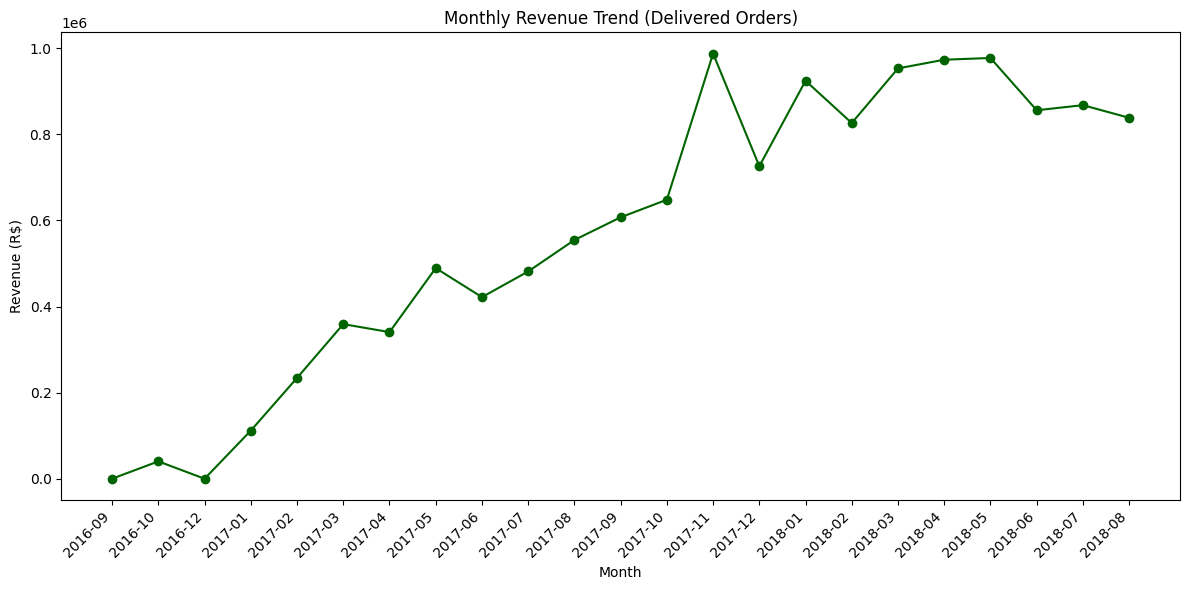

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['month'], monthly_revenue['total_revenue'], marker='o', color='darkgreen')
plt.title('Monthly Revenue Trend (Delivered Orders)')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
#SQL Query
#Delivery Performance
query2 = """
SELECT
    order_id,
    julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS actual_delivery_days,
    julianday(order_estimated_delivery_date) - julianday(order_purchase_timestamp) AS estimated_delivery_days
FROM orders
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
"""

delivery = pd.read_sql(query2, conn)
delivery.describe()

,actual_delivery_days,estimated_delivery_days
count,96470.000000,96470.000000
mean,12.558217,23.736343
std,9.546156,8.761052
min,0.533414,2.008009
25%,6.766204,18.329905
50%,10.217477,23.230880
75%,15.720182,28.407795
max,209.628611,155.135463


In [34]:
#Late delivery rate
delivery['is_late'] = delivery['actual_delivery_days'] > delivery['estimated_delivery_days']
late_rate = delivery['is_late'].mean() * 100
print(f"{late_rate:.2f}% of orders were delivered later than estimated")

8.11% of orders were delivered later than estimated


In [35]:
query3 = """
SELECT
    o.order_id,
    julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) AS actual_delivery_days,
    r.review_score
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
"""

delivery_reviews = pd.read_sql(query3, conn)
delivery_reviews.groupby('review_score')['actual_delivery_days'].mean()

,actual_delivery_days
review_score,
1,21.311499
2,16.660580
3,14.259974
4,12.312356
5,10.688660


In [36]:
#SQL Query
#Top product categories by revenue
query4 = """
SELECT
    p.product_category_name,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(DISTINCT oi.order_id) AS num_orders
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 10
"""

top_categories = pd.read_sql(query4, conn)
top_categories

,product_category_name,total_revenue,num_orders
0,beleza_saude,1233131.72,8647
1,relogios_presentes,1166176.98,5495
2,cama_mesa_banho,1023434.76,9272
3,esporte_lazer,954852.55,7530
4,informatica_acessorios,888724.61,6530
5,moveis_decoracao,711927.69,6307
6,utilidades_domesticas,615628.69,5743
7,cool_stuff,610204.10,3559
8,automotivo,578966.65,3810
9,brinquedos,471286.48,3804


In [38]:
monthly_revenue.head()

,month,total_revenue,num_orders
0,2016-09,134.97,1
1,2016-10,40325.11,265
2,2016-12,10.90,1
3,2017-01,111798.36,750
4,2017-02,234223.40,1653


In [39]:
monthly_revenue.to_csv('monthly_revenue.csv', index=False)

In [40]:
import os
print(os.listdir())

['.config', 'archive (2) (1).zip', 'olist_sellers_dataset.csv', 'olist_products_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'product_category_name_translation.csv', 'archive (2).zip', 'archive (2) (2).zip', 'monthly_revenue.csv', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'sample_data']


In [42]:
from google.colab import files
files.download('monthly_revenue.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
delivery.to_csv('delivery_performance.csv', index=False)
files.download('delivery_performance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
delivery_reviews.to_csv('delivery_vs_reviews.csv', index=False)
files.download('delivery_vs_reviews.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
top_categories.to_csv('top_categories.csv', index=False)
files.download('top_categories.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
query5 = """
SELECT
    o.order_id,
    o.order_status,
    c.customer_state,
    julianday(o.order_purchase_timestamp) AS purchase_date
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
"""

order_status_state = pd.read_sql(query5, conn)
order_status_state.head()

,order_id,order_status,customer_state,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,SP,2.458029e+06
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,BA,2.458324e+06
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,GO,2.458339e+06
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,RN,2.458076e+06
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,SP,2.458163e+06


In [48]:
order_status_state.to_csv('order_status_state.csv', index=False)
files.download('order_status_state.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>